In [24]:
import os
import time
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.backends.cudnn as cudnn
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# Esikäsittelyt, normalisoidaan kuvat käyttöä varten
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
            ),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
            ),
        ]
    ),
    "test": transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
            ),
        ]
    ),
}



In [ ]:
data_dir = "."
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ["train", "val", "test"]
}
dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x], batch_size=32, shuffle=True, num_workers=4
    )
    for x in ["train", "val"]
}
dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val"]}
class_names = image_datasets["train"].classes


device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, "best_model_params.pt")
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f"Epoch {epoch}/{num_epochs - 1}")
            print("-" * 10)

            for phase in ["train", "val"]:
                if phase == "train":
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == "train"):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == "train":
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                if phase == "train":
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = (
                    running_corrects.double() / dataset_sizes[phase]
                )

                print(
                    f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}"
                )

                if phase == "val" and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(
                        model.state_dict(), best_model_params_path
                    )

            print()

        time_elapsed = time.time() - since
        print(
            f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s"
        )
        print(f"Best val Acc: {best_acc:4f}")

        model.load_state_dict(
            torch.load(best_model_params_path, weights_only=True)
        )
    return model

In [26]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

In [ ]:

# RESNET-18

print("--- Koulutetaan ResNet-18 ---")
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)



num_ftrs18 = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs18, len(class_names))
model_resnet18 = model_resnet18.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_18 = optim.SGD(model_resnet18.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler_18 = lr_scheduler.StepLR(
    optimizer_18, step_size=7, gamma=0.1
)

model_resnet18 = train_model(
    model_resnet18,
    criterion,
    optimizer_18,
    exp_lr_scheduler_18,
    num_epochs=11,
)
torch.save(model_resnet18.state_dict(), "resnet18_puulajit.pth")
print("ResNet-18 tallennettu nimellä 'resnet18_puulajit.pth'\n")


#  RESNET-50

print("--- Koulutetaan ResNet-50 ---")
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)



num_ftrs50 = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs50, len(class_names))
model_resnet50 = model_resnet50.to(device)


optimizer_50 = optim.SGD(model_resnet50.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler_50 = lr_scheduler.StepLR(
    optimizer_50, step_size=7, gamma=0.1
)

model_resnet50 = train_model(
    model_resnet50,
    criterion,
    optimizer_50,
    exp_lr_scheduler_50,
    num_epochs=11,
)
torch.save(model_resnet50.state_dict(), "resnet50_puulajit2.pth")
print("ResNet-50 tallennettu nimellä 'resnet50_puulajit2.pth'")

--- Koulutetaan ResNet-18 ---
Epoch 0/10
----------
train Loss: 2.6751 Acc: 0.2499
val Loss: 1.7940 Acc: 0.5373

Epoch 1/10
----------
train Loss: 1.6714 Acc: 0.5519
val Loss: 1.0492 Acc: 0.7261

Epoch 2/10
----------
train Loss: 1.1890 Acc: 0.6673
val Loss: 0.7337 Acc: 0.7822

Epoch 3/10
----------
train Loss: 0.9252 Acc: 0.7353
val Loss: 0.6205 Acc: 0.8216

Epoch 4/10
----------
train Loss: 0.7797 Acc: 0.7756
val Loss: 0.4867 Acc: 0.8672

Epoch 5/10
----------
train Loss: 0.6885 Acc: 0.8018
val Loss: 0.4643 Acc: 0.8548

Epoch 6/10
----------
train Loss: 0.6205 Acc: 0.8203
val Loss: 0.4210 Acc: 0.8797

Epoch 7/10
----------
train Loss: 0.5449 Acc: 0.8449
val Loss: 0.3376 Acc: 0.9004

Epoch 8/10
----------
train Loss: 0.5094 Acc: 0.8613
val Loss: 0.3252 Acc: 0.9108

Epoch 9/10
----------
train Loss: 0.4971 Acc: 0.8616
val Loss: 0.3249 Acc: 0.9212

Epoch 10/10
----------
train Loss: 0.5013 Acc: 0.8587
val Loss: 0.3147 Acc: 0.9170

Training complete in 76m 20s
Best val Acc: 0.921162
ResN

=== TESTITULOKSET: ResNet-18 ===
                                   precision    recall  f1-score   support

                    Acer palmatum     0.8571    0.9000    0.8780        20
                   Cedrus deodara     0.9375    1.0000    0.9677        15
                  Celtis sinensis     1.0000    0.6522    0.7895        23
 Cinnamomum camphora (Linn) Presl     0.8966    0.8966    0.8966        29
            Elaeocarpus decipiens     0.7083    0.8095    0.7556        21
                 Flowering cherry     1.0000    0.3846    0.5556        13
                    Ginkgo biloba     0.7857    0.7857    0.7857        28
          Koelreuteria paniculata     0.9600    0.8571    0.9057        28
             Lagerstroemia indica     0.8750    0.8750    0.8750         8
            Liquidambar formosana     0.9474    0.9000    0.9231        20
            Liriodendron chinense     0.5429    0.8636    0.6667        22
           Magnolia grandiflora L     0.8387    1.0000    0.9123  

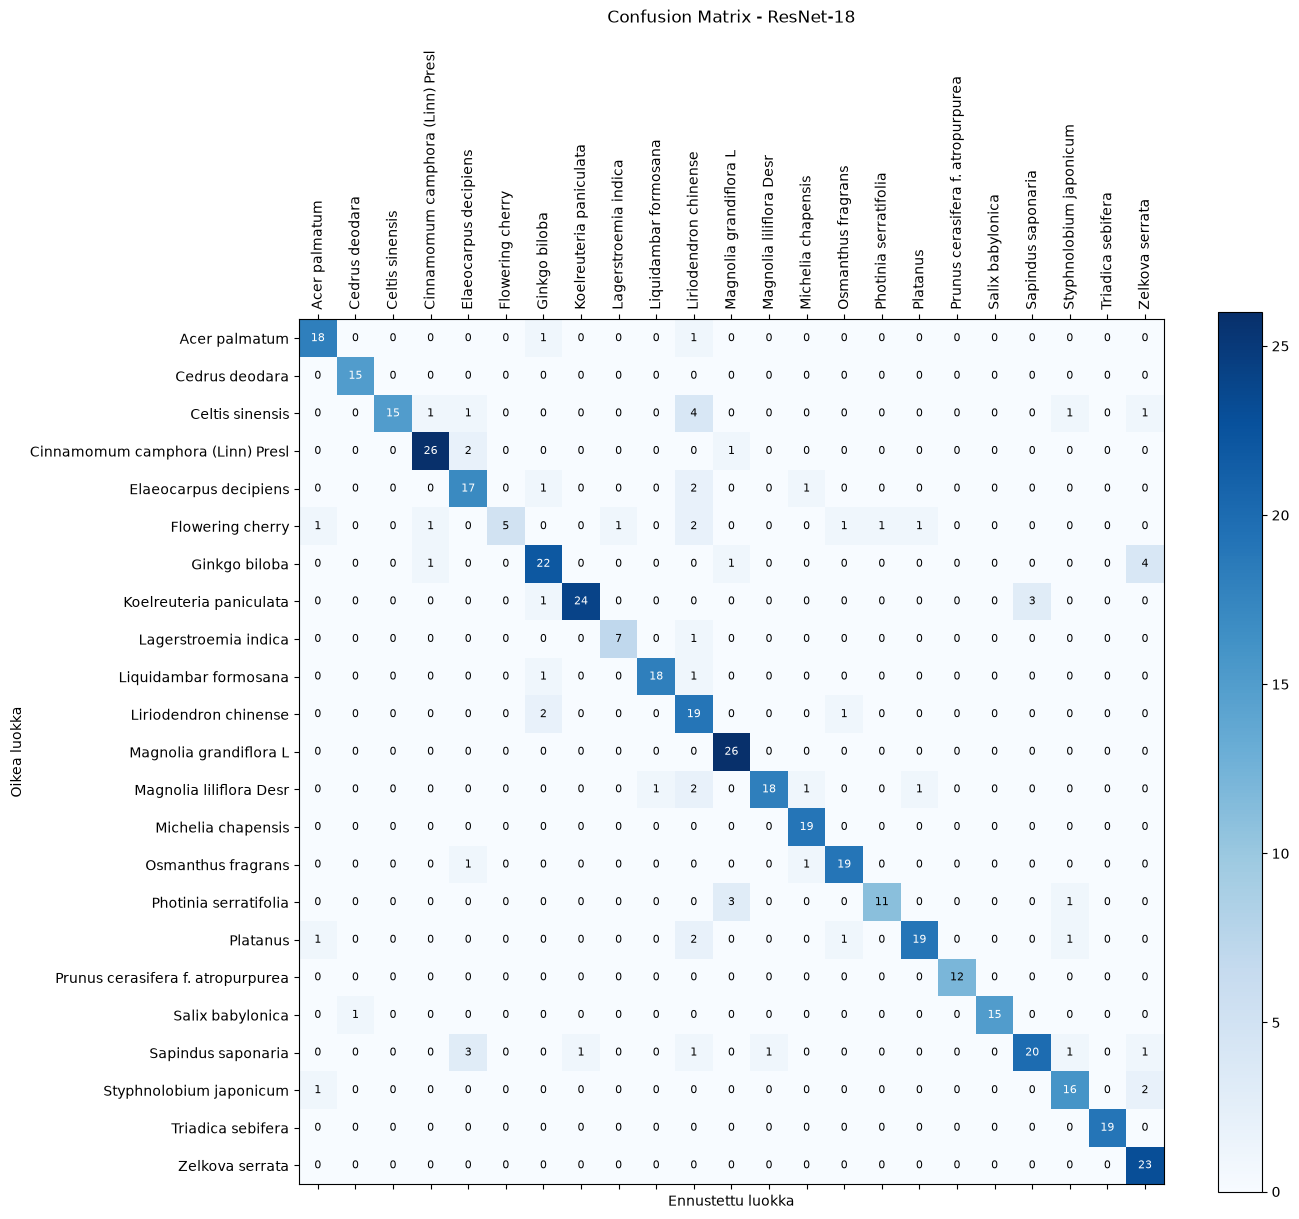

=== TESTITULOKSET: ResNet-50 ===
                                   precision    recall  f1-score   support

                    Acer palmatum     0.7727    0.8500    0.8095        20
                   Cedrus deodara     1.0000    0.9333    0.9655        15
                  Celtis sinensis     0.6818    0.6522    0.6667        23
 Cinnamomum camphora (Linn) Presl     0.7742    0.8276    0.8000        29
            Elaeocarpus decipiens     0.8000    0.7619    0.7805        21
                 Flowering cherry     1.0000    0.3846    0.5556        13
                    Ginkgo biloba     0.8214    0.8214    0.8214        28
          Koelreuteria paniculata     0.8077    0.7500    0.7778        28
             Lagerstroemia indica     0.6154    1.0000    0.7619         8
            Liquidambar formosana     0.7727    0.8500    0.8095        20
            Liriodendron chinense     0.7619    0.7273    0.7442        22
           Magnolia grandiflora L     0.8387    1.0000    0.9123  

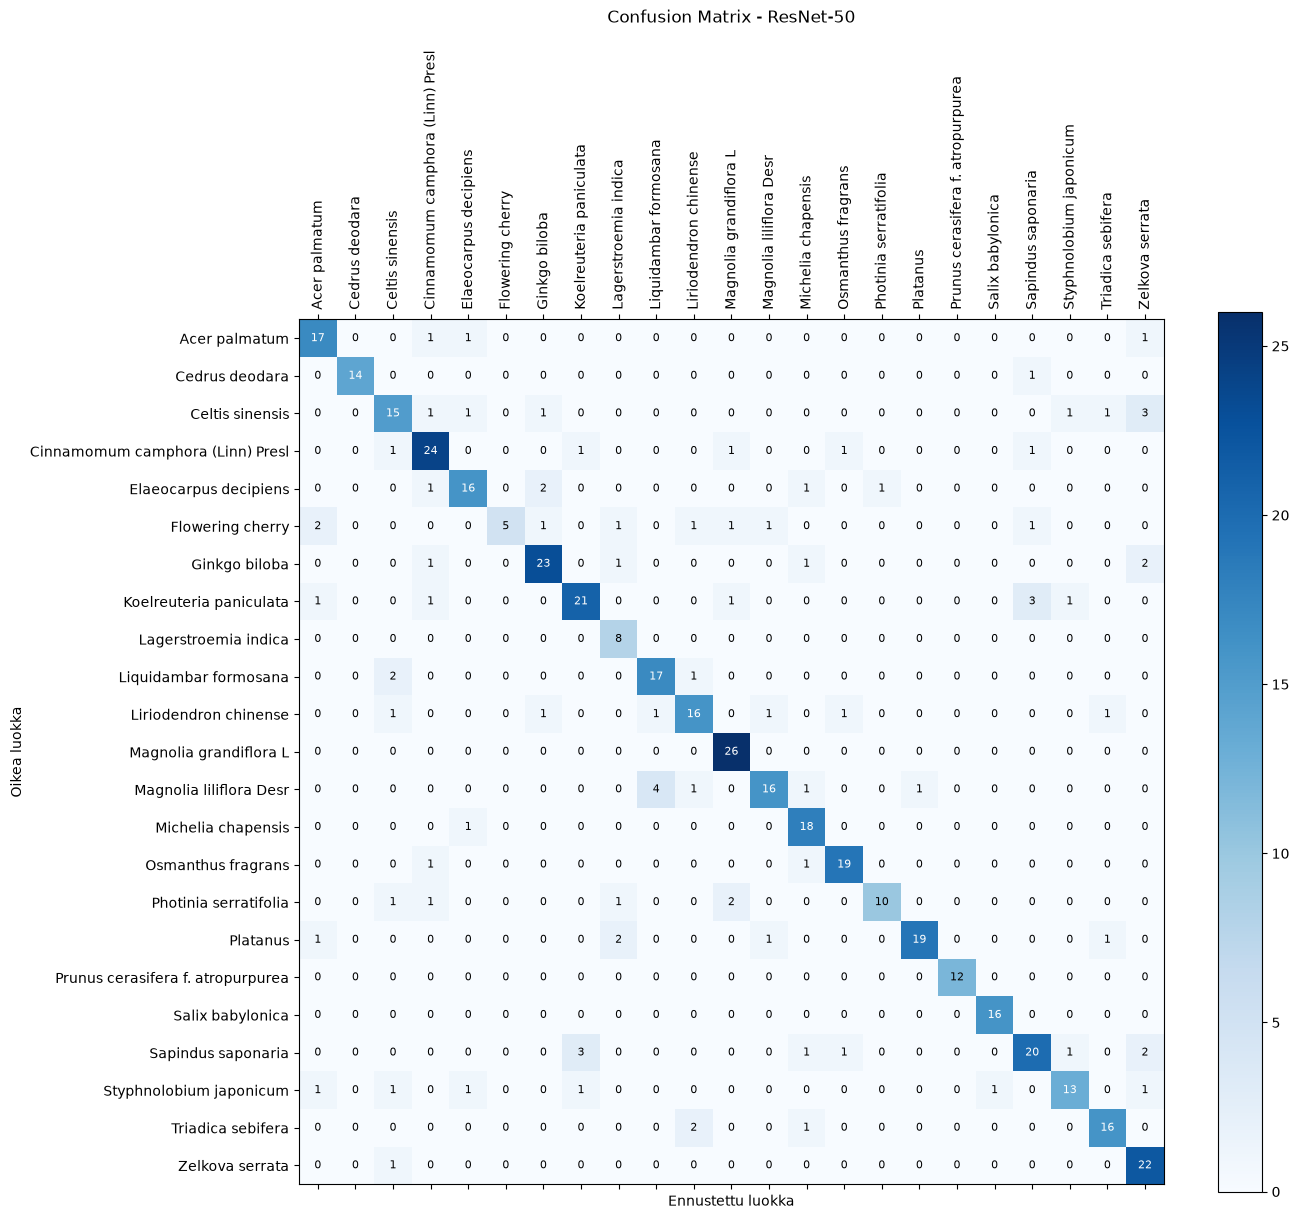

In [ ]:


test_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        ),
    ]
)

data_dir = "."
test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"), test_transform
)

dataloaders = {
    "test": torch.utils.data.DataLoader(
        test_dataset, batch_size=32, shuffle=False, num_workers=4
    )
}

class_names = test_dataset.classes


model_resnet18 = models.resnet18(weights=None)
num_ftrs18 = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs18, len(class_names))

model_resnet18.load_state_dict(
    torch.load("resnet18_puulajit.pth", map_location=device, weights_only=True)
)
model_resnet18 = model_resnet18.to(device)


model_resnet50 = models.resnet50(weights=None)
num_ftrs50 = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs50, len(class_names))

model_resnet50.load_state_dict(
    torch.load("resnet50_puulajit2.pth", map_location=device, weights_only=True)
)
model_resnet50 = model_resnet50.to(device)



def evaluate_on_test_data(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"=== TESTITULOKSET: {model_name} ===")
    print(
        classification_report(
            all_labels, all_preds, target_names=class_names, digits=4
        )
    )

    # Confusion Matrix piirrettynä pelkällä Matplotlibillä
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(14, 12))
    cax = ax.matshow(cm, cmap="Blues")
    fig.colorbar(cax)

    # Lisätään numerot ruutuihin
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                va="center",
                ha="center",
                fontsize=8,
                color="black" if cm[i, j] < cm.max() / 2 else "white",
            )

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)
    plt.title(f"Confusion Matrix - {model_name}", pad=20)
    plt.ylabel("Oikea luokka")
    plt.xlabel("Ennustettu luokka")
    plt.tight_layout()
    plt.show()


# Suoritetaan testaus molemmille malleille
evaluate_on_test_data(model_resnet18, "ResNet-18")
evaluate_on_test_data(model_resnet50, "ResNet-50")

In [ ]:
#Arvioidaan, kuinka todennäköisesti malli olisi oikeassa, jos toinen tai kolmas veikkaus otetaan mukaan. ¨
#Sen jälkeen ei eroa isommin ole, toki koko ajan muuttuu hieman todennäköisemmäksi.

def calculate_top_n_accuracy(model, dataloader, max_n=3):
    model.eval()
    correct_top_n = {n: 0 for n in range(1, max_n + 1)}
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Haetaan N parasta ennustetta kullekin kuvalle
            _, top_preds = outputs.topk(max_n, dim=1)

            total_samples += labels.size(0)

            for n in range(1, max_n + 1):
                # Tarkistetaan onko oikea label N parhaan joukossa
                correct_top_n[n] += (
                    top_preds[:, :n] == labels.view(-1, 1)
                ).sum().item()

    acc_results = {
        n: (correct_top_n[n] / total_samples) * 100
        for n in range(1, max_n + 1)
    }
    return acc_results


print("--- TOP-N TARKKUUKSIEN VERTAILU ---")
max_n = 10
top18 = calculate_top_n_accuracy(model_resnet18, dataloaders["test"], max_n)
top50 = calculate_top_n_accuracy(model_resnet50, dataloaders["test"], max_n)

for n in range(1, max_n + 1):
    print(
        f"Top-{n} Accuracy -> ResNet-18: {top18[n]:.2f}% | ResNet-50: {top50[n]:.2f}%"
    )

    

--- TOP-N TARKKUUKSIEN VERTAILU ---
Top-1 Accuracy -> ResNet-18: 85.38% | ResNet-50: 81.14%
Top-2 Accuracy -> ResNet-18: 91.95% | ResNet-50: 87.50%
Top-3 Accuracy -> ResNet-18: 94.28% | ResNet-50: 92.80%
Top-4 Accuracy -> ResNet-18: 94.92% | ResNet-50: 95.34%
Top-5 Accuracy -> ResNet-18: 96.61% | ResNet-50: 96.61%
Top-6 Accuracy -> ResNet-18: 97.25% | ResNet-50: 97.03%
Top-7 Accuracy -> ResNet-18: 97.67% | ResNet-50: 97.67%
Top-8 Accuracy -> ResNet-18: 97.67% | ResNet-50: 98.52%
Top-9 Accuracy -> ResNet-18: 97.88% | ResNet-50: 98.52%
Top-10 Accuracy -> ResNet-18: 98.31% | ResNet-50: 98.73%
